https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adilshamim8/predict-students-dropout-and-academic-success")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'predict-students-dropout-and-academic-success' dataset.
Path to dataset files: /kaggle/input/predict-students-dropout-and-academic-success


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv(path + "/students_dropout_academic_success.csv")
df.head()


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
df_copy = df.copy()
df_copy['target'] = df_copy['target'].replace({'Dropout': 0, 'Enrolled': 1, 'Graduate': 2})

/tmp/ipykernel_469/48007225.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_copy['target'] = df_copy['target'].replace({'Dropout': 0, 'Enrolled': 1, 'Graduate': 2})


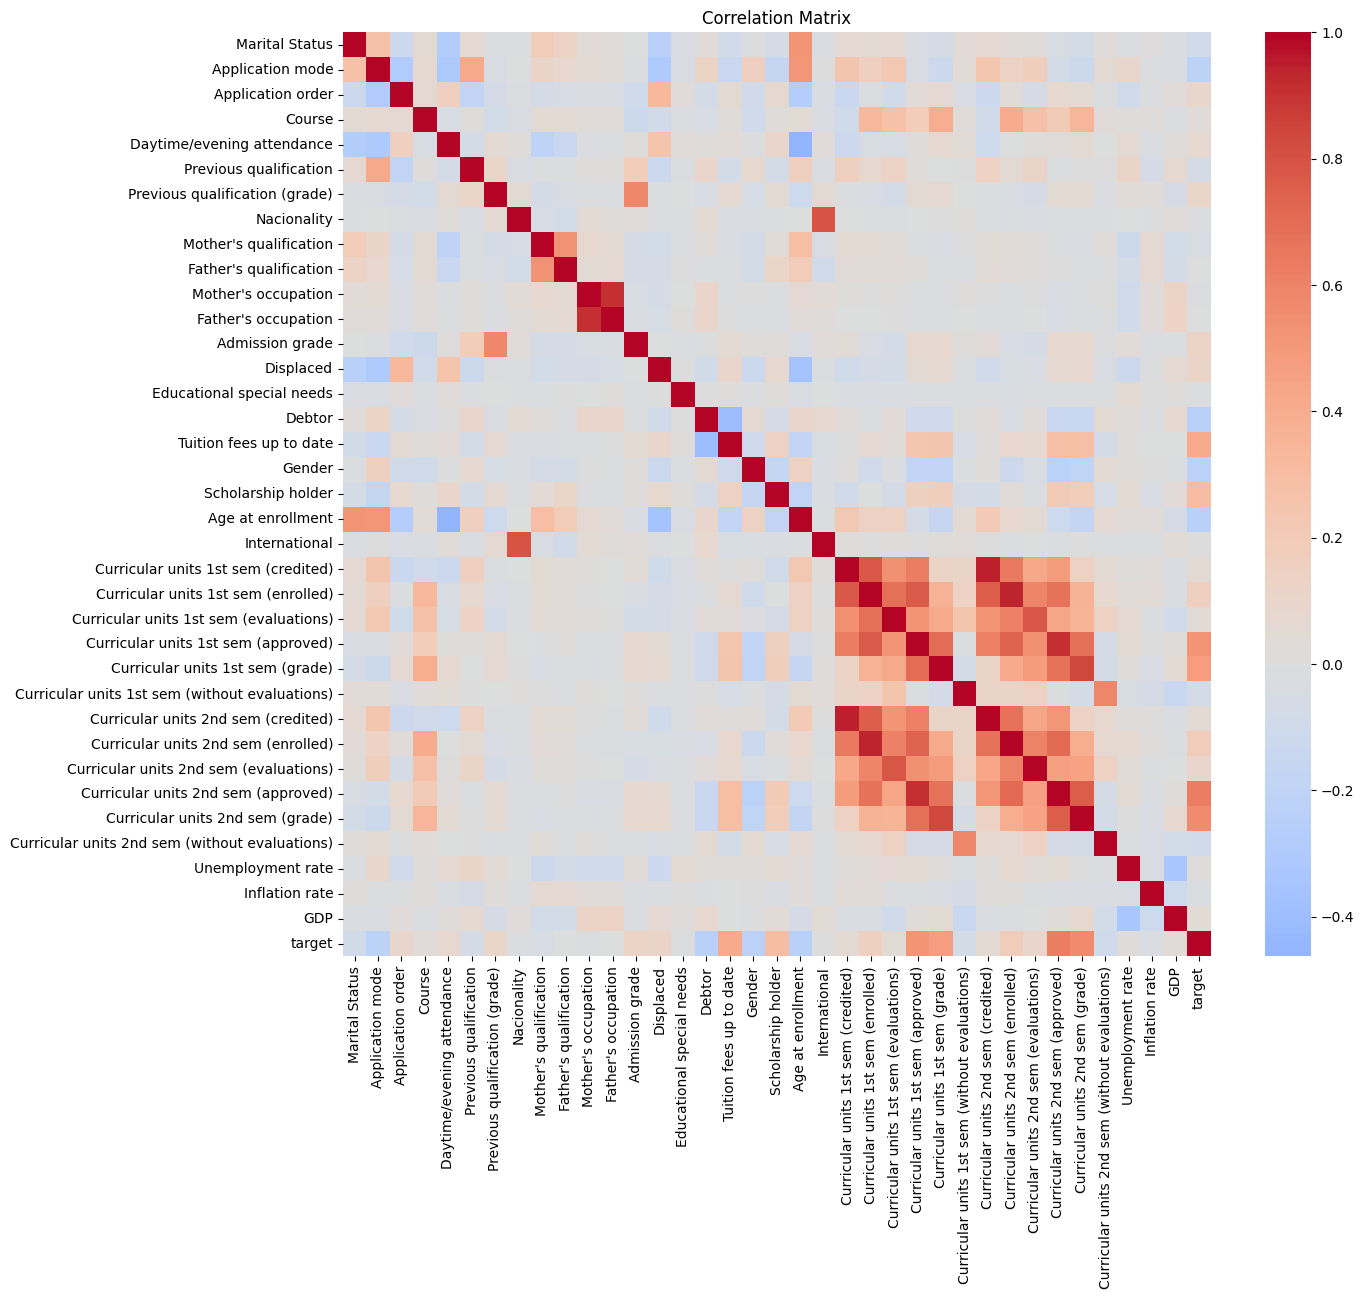

In [ ]:
import seaborn as sns

cols = [
    'Marital Status', 'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance', 'Previous qualification',
    'Previous qualification (grade)', 'Nacionality',
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation", 'Admission grade',
    'Displaced', 'Educational special needs', 'Debtor',
    'Tuition fees up to date', 'Gender', 'Scholarship holder',
    'Age at enrollment', 'International',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate', 'Inflation rate', 'GDP', 'target'
]

corr_matrix = df_copy[cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
for col in df.select_dtypes(include="number").columns:
    q = df[col].quantile([0, 0.25, 0.5, 0.75, 1])
    mode = df[col].mode()[0]
    mean = df[col].mean()
    std = df[col].std()

    print(f"\n{col}")
    print(q.to_string())
    print(f"Mode: {mode}")
    print(f"Mean: {mean}")
    print(f"Std: {std}")
    # print(f"Ouliers: {outliers}")


Marital Status
0.00    1.0
0.25    1.0
0.50    1.0
0.75    1.0
1.00    6.0
Mode: 1
Mean: 1.1785714285714286
Std: 0.6057469461306886

Application mode
0.00     1.0
0.25     1.0
0.50    17.0
0.75    39.0
1.00    57.0
Mode: 1
Mean: 18.669077757685354
Std: 17.48468229100503

Application order
0.00    0.0
0.25    1.0
0.50    1.0
0.75    2.0
1.00    9.0
Mode: 1
Mean: 1.7278481012658229
Std: 1.3137930783621674

Course
0.00      33.0
0.25    9085.0
0.50    9238.0
0.75    9556.0
1.00    9991.0
Mode: 9500
Mean: 8856.642631103074
Std: 2063.566416197537

Daytime/evening attendance
0.00    0.0
0.25    1.0
0.50    1.0
0.75    1.0
1.00    1.0
Mode: 1
Mean: 0.8908227848101266
Std: 0.31189668148179495

Previous qualification
0.00     1.0
0.25     1.0
0.50     1.0
0.75     1.0
1.00    43.0
Mode: 1
Mean: 4.577757685352622
Std: 10.216592341267893

Previous qualification (grade)
0.00     95.0
0.25    125.0
0.50    133.1
0.75    140.0
1.00    190.0
Mode: 133.1
Mean: 132.6133137432188
Std: 13.18833168587628

In [ ]:
print(df.shape)
df.columns

(4424, 37)


Index(['Marital Status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd s

In [ ]:
df["Mother's occupation"].head()
occupation_map = {
    0: "Student",
    1: "Representatives of Legislative/Executive; Directors & Managers",
    2: "Specialists in Intellectual and Scientific Activities",
    3: "Intermediate Level Technicians and Professions",
    4: "Administrative staff",
    5: "Personal Services, Security and Safety Workers and Sellers",
    6: "Farmers and Skilled Workers in Agriculture, Fisheries and Forestry",
    7: "Skilled Workers in Industry, Construction and Craftsmen",
    8: "Installation and Machine Operators and Assembly Workers",
    9: "Unskilled Workers",
    10: "Armed Forces Professions",
    90: "Other Situation",
    99: "(blank)",
    101: "Armed Forces Officers",
    102: "Armed Forces Sergeants",
    103: "Other Armed Forces personnel",
    112: "Directors of administrative and commercial services",
    114: "Hotel, catering, trade and other services directors",
    121: "Specialists in physical sciences, mathematics, engineering and related techniques",
    122: "Health professionals",
    123: "Teachers",
    124: "Specialists in finance, accounting, administrative organization, public and commercial relations",
    125: "ICT Specialists",
    131: "Intermediate level science and engineering technicians and professions",
    132: "Intermediate level health technicians and professionals",
    134: "Intermediate level technicians in legal, social, sports, cultural and similar services",
    135: "Information and communication technology technicians",
    141: "Office workers, secretaries, data processing operators",
    143: "Data/accounting/statistical/financial/registry-related operators",
    144: "Other administrative support staff",
    151: "Personal service workers",
    152: "Sellers",
    153: "Personal care workers and the like",
    154: "Protection and security services personnel",
    161: "Market-oriented farmers and skilled agricultural/animal production workers",
    163: "Subsistence farmers, livestock keepers, fishermen, hunters and gatherers",
    171: "Skilled construction workers (except electricians)",
    172: "Skilled workers in metallurgy, metalworking and similar",
    173: "Printing / Precision / Artisan Workers",
    174: "Skilled workers in electricity and electronics",
    175: "Workers in food processing, woodworking, clothing and other industries and crafts",
    181: "Fixed plant and machine operators",
    182: "Assembly workers",
    183: "Vehicle drivers and mobile equipment operators",
    191: "Cleaning Workers",
    192: "Unskilled workers in agriculture, animal production, fisheries and forestry",
    193: "Unskilled workers in extractive industry, construction, manufacturing and transport",
    194: "Meal preparation assistants",
    195: "Street vendors (except food) and street service providers",
}

df["Mother's occupation label"] = df["Mother's occupation"].map(occupation_map)
df["Father's occupation label"] = df["Father's occupation"].map(occupation_map)

In [ ]:
dropouts = df[df['target'] == "Dropout"]
gender_counts = (
    df.groupby(["Father's occupation label", "target", "Gender"])
      .size()
      .unstack()
)
gender_proportions = (
    gender_counts.div(gender_counts.sum(axis=1), axis=0)
)


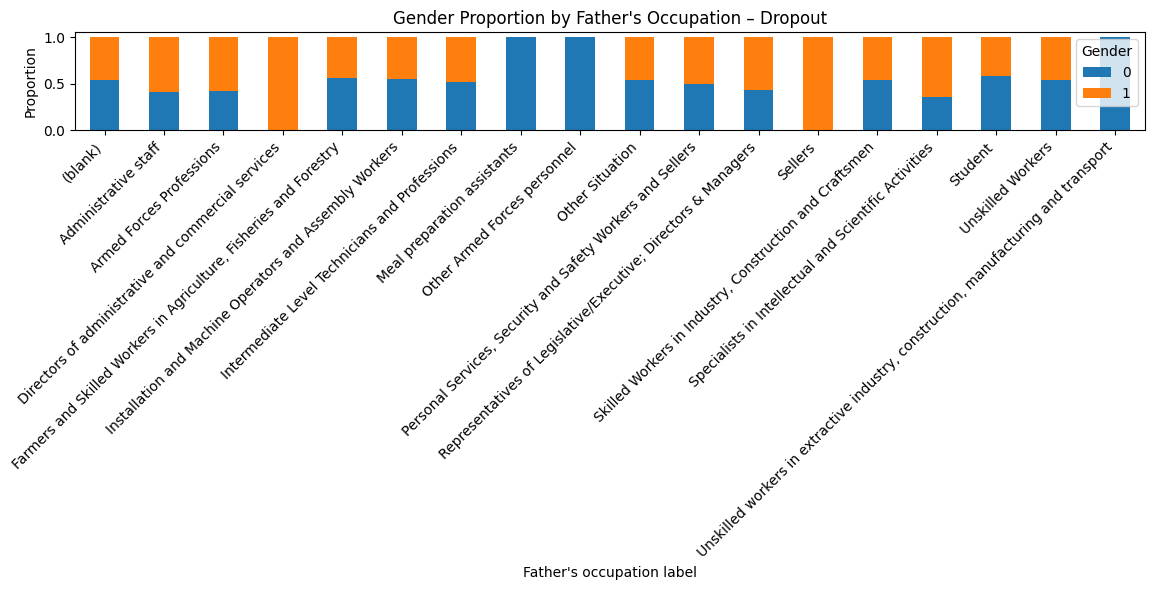

In [ ]:
gender_proportions.xs("Dropout", level="target") \
    .plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Gender   Proportion by Father's Occupation – Dropout")
plt.ylabel("Proportion")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

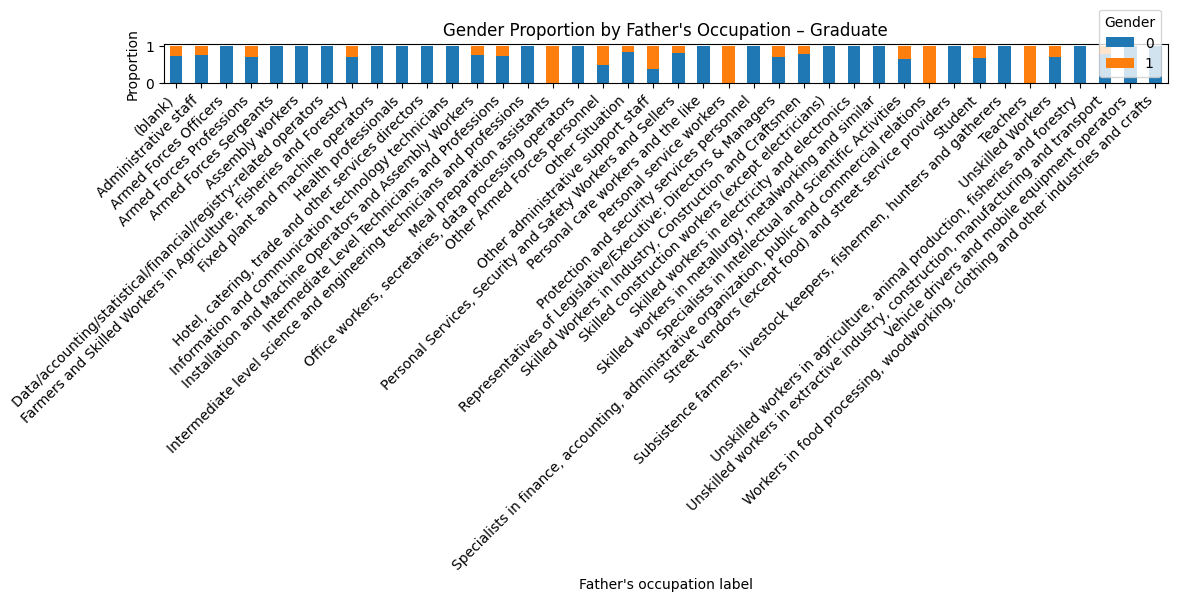

In [ ]:
gender_proportions.xs("Graduate", level="target") \
    .plot(kind="bar", stacked=True, figsize=(12,6))

plt.title("Gender Proportion by Father's Occupation – Graduate")
plt.ylabel("Proportion")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

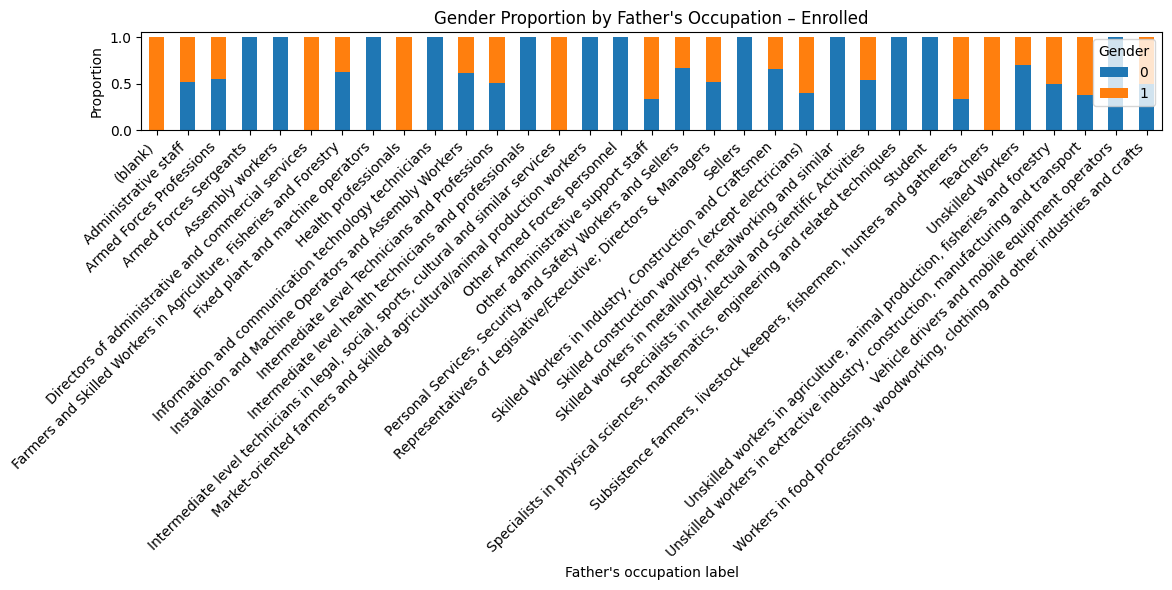

In [ ]:

gender_proportions.xs("Enrolled", level="target") \
    .plot(kind="bar", stacked=True, figsize=(12,6))

plt.title("Gender Proportion by Father's Occupation – Enrolled")
plt.ylabel("Proportion")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

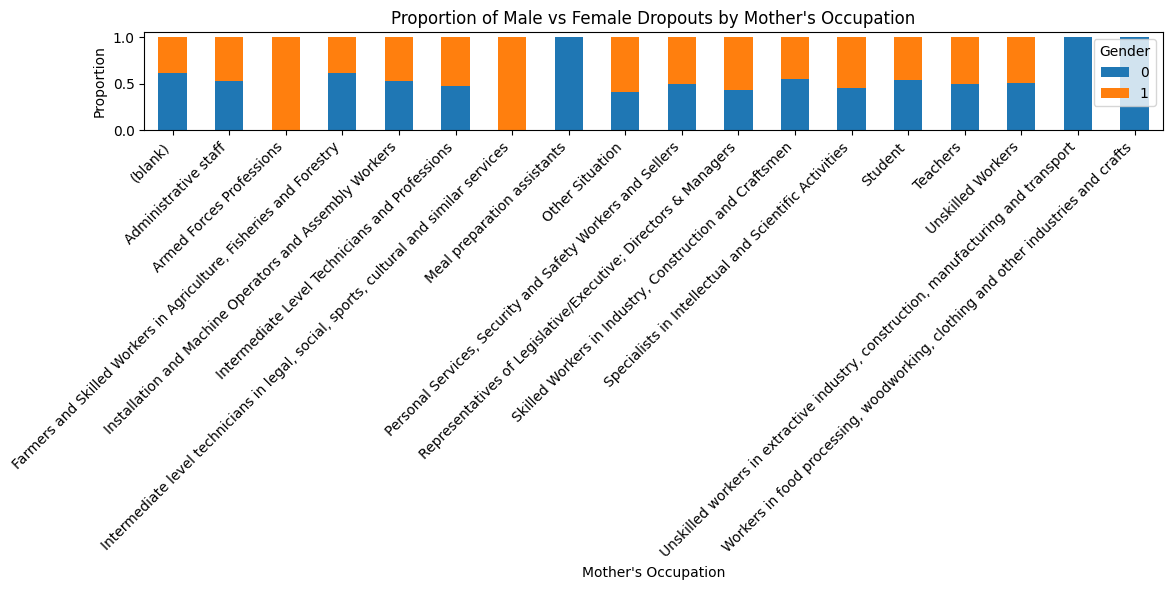

In [ ]:
dropouts = df[df["target"] == "Dropout"].copy()
gender_counts = (
    dropouts.groupby(["Mother's occupation label", "Gender"])
            .size()
            .unstack(fill_value=0)
)

gender_proportions = gender_counts.div(gender_counts.sum(axis=1), axis=0)

ax = gender_proportions.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

ax.set_title("Proportion of Male vs Female Dropouts by Mother's Occupation")
ax.set_ylabel("Proportion")
ax.set_xlabel("Mother's Occupation")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

1: Never Married

2: Married

3: Civil Union/Cohabiting

4: Separated

5: Divorced

6: Widowed

In [ ]:
df_num = df.drop(["Mother's occupation label", "Father's occupation label"], axis=1)


KeyError: '["Mother\'s occupation label", "Father\'s occupation label"] not found in axis'

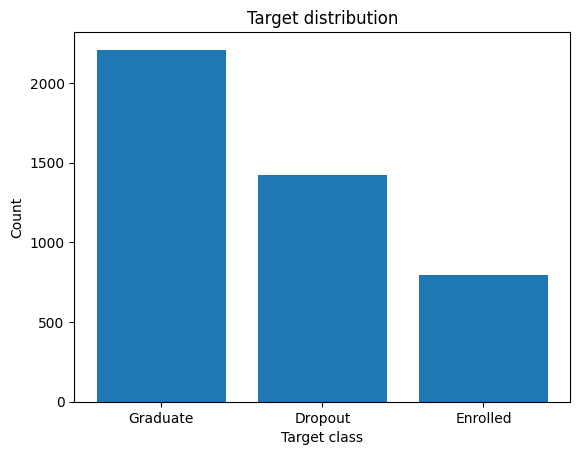

In [ ]:
import matplotlib.pyplot as plt
counts = df["target"].value_counts(dropna=False)
plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Target class")
plt.ylabel("Count")
plt.title("Target distribution")
plt.xticks(rotation=0)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Separate features and target
X = df_num.drop("target", axis=1)
y = df_num["target"]


le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded   # keeps class balance
)

model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6598870056497175

Classification Report:

              precision    recall  f1-score   support

     Dropout       0.72      0.67      0.69       284
    Enrolled       0.27      0.18      0.22       159
    Graduate       0.71      0.83      0.76       442

    accuracy                           0.66       885
   macro avg       0.57      0.56      0.56       885
weighted avg       0.63      0.66      0.64       885


Confusion Matrix:

[[189  36  59]
 [ 40  29  90]
 [ 33  43 366]]


In [27]:
import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB, GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df.drop(columns=["target"]).copy()
y = df["target"]

le = LabelEncoder()
y_enc = le.fit_transform(y)

# Define columns
numeric_cols = ["Inflation rate", "GDP", "Previous qualification (grade)", "Admission grade",
                'Curricular units 1st sem (credited)',
                'Curricular units 1st sem (enrolled)',
                'Curricular units 1st sem (evaluations)',
                'Curricular units 1st sem (approved)',
                'Curricular units 1st sem (grade)',
                'Curricular units 1st sem (without evaluations)',
                'Curricular units 2nd sem (credited)',
                'Curricular units 2nd sem (enrolled)',
                'Curricular units 2nd sem (evaluations)',
                'Curricular units 2nd sem (approved)',
                'Curricular units 2nd sem (grade)',
                'Curricular units 2nd sem (without evaluations)',
                "Unemployment rate", "Age at enrollment"]

cat_cols = [c for c in X.columns if c not in numeric_cols]


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accs = []
all_true = []
all_pred = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y_enc), start=1):
    X_train, X_val = X.iloc[tr_idx], X.iloc[va_idx]
    y_train, y_val = y_enc[tr_idx], y_enc[va_idx]

    # categorical
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

    Xtr_cat = enc.fit_transform(X_train[cat_cols])
    Xva_cat = enc.transform(X_val[cat_cols])

    # compute train max per column for safe "unknown bucket"
    max_train = np.max(Xtr_cat, axis=0).astype(int)
    min_cats = (max_train + 2).astype(int)


    for j in range(Xtr_cat.shape[1]):
        unk = max_train[j] + 1
        Xtr_cat[:, j] = np.where(Xtr_cat[:, j] < 0, unk, Xtr_cat[:, j])
        Xva_cat[:, j] = np.where(Xva_cat[:, j] < 0, unk, Xva_cat[:, j])
        Xva_cat[:, j] = np.where(Xva_cat[:, j] > unk, unk, Xva_cat[:, j])

    Xtr_cat = Xtr_cat.astype(int)
    Xva_cat = Xva_cat.astype(int)

    cat_nb = CategoricalNB(min_categories=min_cats)
    cat_nb.fit(Xtr_cat, y_train)
    logp_cat = cat_nb.predict_log_proba(Xva_cat)

    # safety check
    assert (Xva_cat.max(axis=0) <= (Xtr_cat.max(axis=0) + 1)).all()

    # numeric
    Xtr_num = X_train[numeric_cols].copy()
    Xva_num = X_val[numeric_cols].copy()

    med = Xtr_num.median()
    Xtr_num = Xtr_num.fillna(med)
    Xva_num = Xva_num.fillna(med)

    gauss_nb = GaussianNB()
    gauss_nb.fit(Xtr_num, y_train)
    logp_num = gauss_nb.predict_log_proba(Xva_num)

    # combine
    logp_combined = logp_cat + logp_num
    y_pred = np.argmax(logp_combined, axis=1)

    fold_acc = accuracy_score(y_val, y_pred)
    accs.append(fold_acc)

    all_true.append(y_val)
    all_pred.append(y_pred)

    print(f"Fold {fold}: accuracy = {fold_acc:.4f}")

# overall results
all_true = np.concatenate(all_true)
all_pred = np.concatenate(all_pred)

print("\nCV Accuracy: mean =", np.mean(accs), "std =", np.std(accs))
print("\nOverall Classification Report:\n")
print(classification_report(all_true, all_pred))
print("\nOverall Confusion Matrix:\n")
print(confusion_matrix(all_true, all_pred))

Fold 1: accuracy = 0.7085
Fold 2: accuracy = 0.7243
Fold 3: accuracy = 0.7209
Fold 4: accuracy = 0.7096
Fold 5: accuracy = 0.6867

CV Accuracy: mean = 0.70998568397372 std = 0.013197267667890577

Overall Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.65      0.71      1421
           1       0.44      0.36      0.40       794
           2       0.75      0.87      0.81      2209

    accuracy                           0.71      4424
   macro avg       0.65      0.63      0.64      4424
weighted avg       0.70      0.71      0.70      4424


Overall Confusion Matrix:

[[ 924  237  260]
 [ 123  286  385]
 [ 150  128 1931]]


<Figure size 640x480 with 0 Axes>

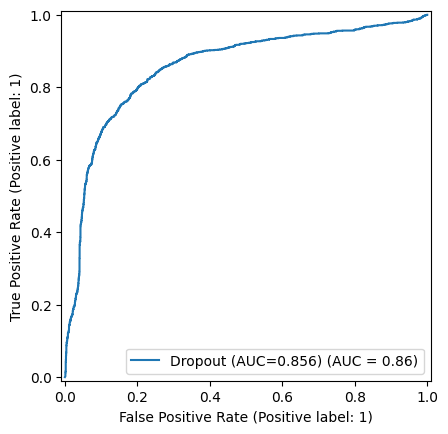

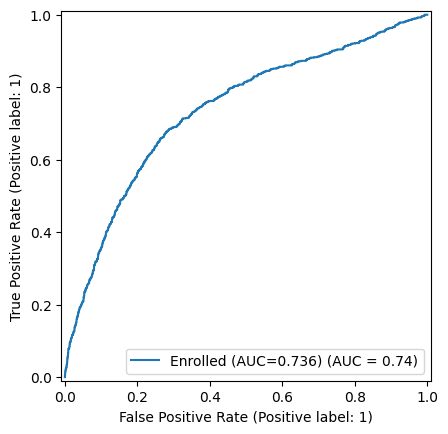

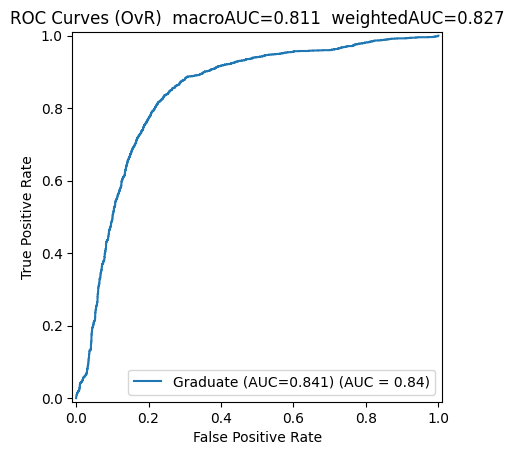

In [30]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB, GaussianNB
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import label_binarize

X = df.drop(columns=["target"]).copy()
y = df["target"]

le = LabelEncoder()
y_enc = le.fit_transform(y)
classes = np.unique(y_enc)
n_classes = len(classes)

# Define columns
numeric_cols = ["Inflation rate", "GDP", "Previous qualification (grade)", "Admission grade",
                'Curricular units 1st sem (credited)',
                'Curricular units 1st sem (enrolled)',
                'Curricular units 1st sem (evaluations)',
                'Curricular units 1st sem (approved)',
                'Curricular units 1st sem (grade)',
                'Curricular units 1st sem (without evaluations)',
                'Curricular units 2nd sem (credited)',
                'Curricular units 2nd sem (enrolled)',
                'Curricular units 2nd sem (evaluations)',
                'Curricular units 2nd sem (approved)',
                'Curricular units 2nd sem (grade)',
                'Curricular units 2nd sem (without evaluations)',
                "Unemployment rate", "Age at enrollment"]

cat_cols = [c for c in X.columns if c not in numeric_cols]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_true = []
all_proba = []   # store predicted probabilities (out-of-fold)

def softmax_from_logp(logp):
    # stable softmax for log-probabilities (row-wise)
    m = np.max(logp, axis=1, keepdims=True)
    exp = np.exp(logp - m)
    return exp / np.sum(exp, axis=1, keepdims=True)

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y_enc), start=1):
    X_train, X_val = X.iloc[tr_idx], X.iloc[va_idx]
    y_train, y_val = y_enc[tr_idx], y_enc[va_idx]

    # --- categorical branch ---
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    Xtr_cat = enc.fit_transform(X_train[cat_cols])
    Xva_cat = enc.transform(X_val[cat_cols])

    max_train = np.max(Xtr_cat, axis=0).astype(int)
    min_cats = (max_train + 2).astype(int)

    for j in range(Xtr_cat.shape[1]):
        unk = max_train[j] + 1
        Xtr_cat[:, j] = np.where(Xtr_cat[:, j] < 0, unk, Xtr_cat[:, j])
        Xva_cat[:, j] = np.where(Xva_cat[:, j] < 0, unk, Xva_cat[:, j])
        Xva_cat[:, j] = np.where(Xva_cat[:, j] > unk, unk, Xva_cat[:, j])

    Xtr_cat = Xtr_cat.astype(int)
    Xva_cat = Xva_cat.astype(int)

    cat_nb = CategoricalNB(min_categories=min_cats)
    cat_nb.fit(Xtr_cat, y_train)
    logp_cat = cat_nb.predict_log_proba(Xva_cat)

    # --- numeric branch ---
    Xtr_num = X_train[numeric_cols].copy()
    Xva_num = X_val[numeric_cols].copy()

    med = Xtr_num.median()
    Xtr_num = Xtr_num.fillna(med)
    Xva_num = Xva_num.fillna(med)

    gauss_nb = GaussianNB()
    gauss_nb.fit(Xtr_num, y_train)
    logp_num = gauss_nb.predict_log_proba(Xva_num)

    # --- combine (log space) ---
    logp_combined = logp_cat + logp_num

    # convert combined log-probs to probs for ROC/AUC
    proba = softmax_from_logp(logp_combined)

    all_true.append(y_val)
    all_proba.append(proba)

# ---- concatenate out-of-fold truth and probabilities ----
y_true = np.concatenate(all_true)
y_score = np.vstack(all_proba)   # shape (n_samples, n_classes)

# ---- AUC computation + ROC plot ----
plt.figure()

if n_classes == 2:
    # binary: use positive class prob (class 1)
    auc = roc_auc_score(y_true, y_score[:, 1])
    RocCurveDisplay.from_predictions(y_true, y_score[:, 1], name=f"AUC = {auc:.3f}")
    plt.title("ROC Curve (Binary)")

else:
    # multiclass OvR
    y_true_bin = label_binarize(y_true, classes=classes)

    auc_macro = roc_auc_score(y_true_bin, y_score, average="macro", multi_class="ovr")
    auc_weighted = roc_auc_score(y_true_bin, y_score, average="weighted", multi_class="ovr")

    # plot one ROC curve per class (OvR)
    for k, cls in enumerate(classes):
        RocCurveDisplay.from_predictions(
            y_true_bin[:, k],
            y_score[:, k],
            name=f"{le.inverse_transform([cls])[0]} (AUC={roc_auc_score(y_true_bin[:, k], y_score[:, k]):.3f})"
        )

    plt.title(f"ROC Curves (OvR)  macroAUC={auc_macro:.3f}  weightedAUC={auc_weighted:.3f}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
df_num = df.drop(['Curricular units 1st sem (credited)',
                'Curricular units 1st sem (enrolled)',
                'Curricular units 1st sem (evaluations)',
                'Curricular units 1st sem (approved)',
                'Curricular units 1st sem (grade)',
                'Curricular units 1st sem (without evaluations)',
                'Curricular units 2nd sem (credited)',
                'Curricular units 2nd sem (enrolled)',
                'Curricular units 2nd sem (evaluations)',
                'Curricular units 2nd sem (approved)',
                'Curricular units 2nd sem (grade)',
                'Curricular units 2nd sem (without evaluations)',], axis=1)

In [31]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB, GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df_num.drop(columns=["target"]).copy()
y = df_num["target"]

le = LabelEncoder()
y_enc = le.fit_transform(y)

# Define columns
numeric_cols = ["Inflation rate", "GDP", "Previous qualification (grade)", "Admission grade",
                "Unemployment rate", "Age at enrollment"]

cat_cols = [c for c in X.columns if c not in numeric_cols]


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accs = []
all_true = []
all_pred = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y_enc), start=1):
    X_train, X_val = X.iloc[tr_idx], X.iloc[va_idx]
    y_train, y_val = y_enc[tr_idx], y_enc[va_idx]

    # categorical
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

    Xtr_cat = enc.fit_transform(X_train[cat_cols])
    Xva_cat = enc.transform(X_val[cat_cols])

    # compute train max per column for safe "unknown bucket"
    max_train = np.max(Xtr_cat, axis=0).astype(int)
    min_cats = (max_train + 2).astype(int)


    for j in range(Xtr_cat.shape[1]):
        unk = max_train[j] + 1
        Xtr_cat[:, j] = np.where(Xtr_cat[:, j] < 0, unk, Xtr_cat[:, j])
        Xva_cat[:, j] = np.where(Xva_cat[:, j] < 0, unk, Xva_cat[:, j])
        Xva_cat[:, j] = np.where(Xva_cat[:, j] > unk, unk, Xva_cat[:, j])

    Xtr_cat = Xtr_cat.astype(int)
    Xva_cat = Xva_cat.astype(int)

    cat_nb = CategoricalNB(min_categories=min_cats)
    cat_nb.fit(Xtr_cat, y_train)
    logp_cat = cat_nb.predict_log_proba(Xva_cat)

    # safety check
    assert (Xva_cat.max(axis=0) <= (Xtr_cat.max(axis=0) + 1)).all()

    # numeric
    Xtr_num = X_train[numeric_cols].copy()
    Xva_num = X_val[numeric_cols].copy()

    med = Xtr_num.median()
    Xtr_num = Xtr_num.fillna(med)
    Xva_num = Xva_num.fillna(med)

    gauss_nb = GaussianNB()
    gauss_nb.fit(Xtr_num, y_train)
    logp_num = gauss_nb.predict_log_proba(Xva_num)

    # combine
    logp_combined = logp_cat + logp_num
    y_pred = np.argmax(logp_combined, axis=1)

    fold_acc = accuracy_score(y_val, y_pred)
    accs.append(fold_acc)

    all_true.append(y_val)
    all_pred.append(y_pred)

    print(f"Fold {fold}: accuracy = {fold_acc:.4f}")

# overall results
all_true = np.concatenate(all_true)
all_pred = np.concatenate(all_pred)

print("\nCV Accuracy: mean =", np.mean(accs), "std =", np.std(accs))
print("\nOverall Classification Report:\n")
print(classification_report(all_true, all_pred))
print("\nOverall Confusion Matrix:\n")
print(confusion_matrix(all_true, all_pred))

Fold 1: accuracy = 0.6237
Fold 2: accuracy = 0.6169
Fold 3: accuracy = 0.6136
Fold 4: accuracy = 0.6294
Fold 5: accuracy = 0.6086

CV Accuracy: mean = 0.6184426208553826 std = 0.007355890936540861

Overall Classification Report:

              precision    recall  f1-score   support

           0       0.62      0.59      0.60      1421
           1       0.42      0.10      0.17       794
           2       0.63      0.82      0.71      2209

    accuracy                           0.62      4424
   macro avg       0.56      0.50      0.49      4424
weighted avg       0.59      0.62      0.58      4424


Overall Confusion Matrix:

[[ 834   57  530]
 [ 180   82  532]
 [ 334   55 1820]]


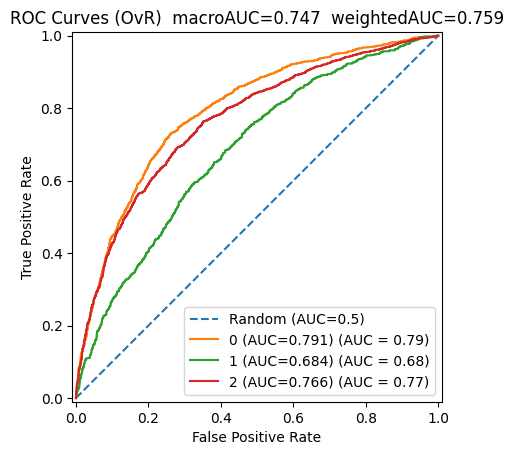

In [38]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import label_binarize

# after your CV loop:
# y_true = np.concatenate(all_true)
# y_score = np.vstack(all_proba)   # shape (n_samples, n_classes)
classes = np.unique(y_true)
n_classes = len(classes)

fig, ax = plt.subplots()

# baseline
ax.plot([0, 1], [0, 1], linestyle="--", label="Random (AUC=0.5)")

if n_classes == 2:
    # one curve, positive class probability is column 1
    auc = roc_auc_score(y_true, y_score[:, 1])
    RocCurveDisplay.from_predictions(
        y_true,
        y_score[:, 1],
        name=f"Positive class (AUC={auc:.3f})",
        ax=ax
    )
    ax.set_title("ROC Curve")

else:
    # multiclass one-vs-rest
    y_true_bin = label_binarize(y_true, classes=classes)

    # optional summary AUCs (not curves, just numbers)
    auc_macro = roc_auc_score(y_true_bin, y_score, average="macro", multi_class="ovr")
    auc_weighted = roc_auc_score(y_true_bin, y_score, average="weighted", multi_class="ovr")

    for k, cls in enumerate(classes):
        auc_k = roc_auc_score(y_true_bin[:, k], y_score[:, k])
        cls_name = str(cls)  # or use le.inverse_transform([cls])[0] if you want original labels
        RocCurveDisplay.from_predictions(
            y_true_bin[:, k],
            y_score[:, k],
            name=f"{cls_name} (AUC={auc_k:.3f})",
            ax=ax
        )

    ax.set_title(f"ROC Curves (OvR)  macroAUC={auc_macro:.3f}  weightedAUC={auc_weighted:.3f}")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7638418079096045

Classification Report:

              precision    recall  f1-score   support

     Dropout       0.79      0.77      0.78       284
    Enrolled       0.50      0.32      0.39       159
    Graduate       0.80      0.92      0.86       442

    accuracy                           0.76       885
   macro avg       0.70      0.67      0.68       885
weighted avg       0.74      0.76      0.75       885


Confusion Matrix:

[[218  30  36]
 [ 44  51  64]
 [ 14  21 407]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:

from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


rf = RandomForestClassifier(
    n_estimators=200,      # number of trees
    max_depth=None,        # let trees grow fully
    random_state=42
)

rf = RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1)

param_dist = {
    "n_estimators": [200, 400, 600, 800, 1000],
    "max_depth": [None, 8, 12, 16, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.5, 0.8],
    "bootstrap": [True, False],
}

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=40,
    scoring="recall",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV score:", search.best_score_)

best_rf = search.best_estimator_

y_pred = best_rf.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Fitting 5 folds for each of 40 candidates, totalling 200 fits


In [ ]:

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)


importances.head(15).plot(kind="barh", figsize=(8,6))
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.show()

NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
# drop features that happen after students have taking classes -- at enrollment dropouut prediction
from sklearn.model_selection import RandomizedSearchCV

X = df.drop(columns=[c for c in df.columns if "sem" in c] + ["target", "Mother's occupation label", "Father's occupation label"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

rf = RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1)

param_dist = {
    "n_estimators": [200, 400, 600, 800, 1000],
    "max_depth": [None, 8, 12, 16, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.5, 0.8],
    "bootstrap": [True, False],
}

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=40,
    scoring="recall",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV score:", search.best_score_)

best_rf = search.best_estimator_

y_pred = best_rf.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 16, 'bootstrap': False}
Best CV score: 0.6318069363490151
Test accuracy: 0.6056497175141243
              precision    recall  f1-score   support

     Dropout       0.62      0.62      0.62       284
    Enrolled       0.34      0.35      0.34       159
    Graduate       0.69      0.69      0.69       442

    accuracy                           0.61       885
   macro avg       0.55      0.55      0.55       885
weighted avg       0.61      0.61      0.61       885



In [ ]:
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(imp.head(10))

Admission grade                   0.099971
Previous qualification (grade)    0.085497
Age at enrollment                 0.085457
Course                            0.078858
Tuition fees up to date           0.072322
Father's occupation               0.066569
Mother's occupation               0.058552
Application mode                  0.048094
GDP                               0.047447
Mother's qualification            0.047081
dtype: float64
